# TP-1 — TinyGPT: pretraining, decodificación y Mixture of Experts

Autor: Msc. Abraham R.

Vas a preentrenar un GPT muy pequeño (un decoder transformer) a nivel de caracteres sobre
Shakespeare, y después trabajarlo en dos direcciones.

## Arquitecturas de TinyGPT

Pensado para la [materia NLP-II](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG),
donde tratamos arquitecturas y teoría, vamos a empezar con un modelo denso, equivalente y
basado en GPT-2, para terminar en un modelo que consiste en un **GPT de Mixture of
Experts**, equivalente a modelos como:
- DeepSeek-MoE/v2/v3/R1
- Qwen-MoE
- Mistral/Mixtral

**Parte 1 — Inferencia.** El modelo te da una distribución de probabilidad sobre el
siguiente carácter. *Elegir* un carácter a partir de ella es una decisión de diseño
aparte, y cambia la salida mucho más de lo que lo haría otra época de entrenamiento.

**Parte 2 — Arquitectura.** Reemplazá el bloque feed-forward denso por un Mixture of
Experts, y medí qué te da y qué te cuesta.

Se entrena un solo modelo, una sola vez, al principio, y se reutiliza en todo el trabajo.

## Consignas

**Parte 1**
- Consigna I — implementar `generateV2`: greedy, temperatura, top-k y top-p.
- Consigna II — comparar las estrategias de decodificación y explicar qué hace cada perilla.
- Consigna III — medir qué te da realmente el KV-cache. No asumas que gana.
- Consigna IV — leer e interpretar los mapas de atención de tu modelo entrenado.

**Parte 2**
- Consigna V — implementar ruteo top-k en `MoELayer.forward`.
- Consigna VI — entrenar TinyGPT-MoE y compararlo contra el baseline denso.
- Consigna VII — medir la utilización de expertos y diagnosticar colapso de ruteo.
- Consigna VIII — implementar [DeepSeekMoE](https://arxiv.org/pdf/2401.06066) y medirlo.
- Consigna IX — tu MoE es mucho más lento por paso que el modelo denso. Hacelo más rápido.

**Después**
- Consigna X — preentrenar el modelo *denso* con un tokenizer subword real de GPT-2 y
  comparar como corresponde. El TP-2 y el notebook del TP-3 dependen del checkpoint que
  produce esta consigna.
- *Opcional* — una loss auxiliar de balanceo de carga.

## Cómo trabajar en esto

Toda consigna de la que dependa una celda posterior viene con una celda `check_*()`.
Corréla antes de seguir — cuesta segundos y atrapa los bugs que si no aparecerían como
una curva de loss plana media hora más tarde. Que pasen todos los self-checks es el mínimo
para entregar.



In [1]:
import time
from typing import List, Optional

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader

from tinygpt import (
    CharDataset,
    CharTokenizer,
    GPTConfig,
    MoEArgs,
    count_parameters,
    describe,
    free,
    load_checkpoint,
    get_device,
    load_tinyshakespeare,
    plot_losses,
    resume,
    run_training,
    trim_kv_cache,
    visualize_attention,
)
from trainer import Trainer

torch.manual_seed(1337)

## Retomar después de reiniciar el kernel

Este notebook entrena cuatro modelos y los mantiene en memoria, así que un reinicio los
pierde a todos y toda celda de acá para abajo falla con `NameError`. Los pesos y las curvas
de loss están en disco, así que no hace falta reentrenar — corré la celda de abajo y saltá
hasta donde estabas.

En una corrida desde cero no la toques: sólo restaura lo que ya está terminado.


In [2]:
def resume_all():
    """
    Reconstruye los modelos que ya tengan un checkpoint terminado.

    Corré primero las celdas de arriba -- las definiciones son instantáneas, lo único que no
    lo es es el entrenamiento -- y después llamá a esto. Restaura cada modelo y su curva de
    loss, y saltea todo aquello cuya clase o config todavía no esté en memoria.
    """
    import os

    g = globals()
    specs = [
        ("model",     "./checkpoints/tp1_dense",    "history",     ("config",)),
        ("moe_model", "./checkpoints/tp1_moe",      "history_moe", ("moe_config",)),
        ("ds_model",  "./checkpoints/tp1_deepseek", "history_ds",  ("ds_config",)),
        ("sub_model", "./checkpoints/tp1_subword",  "sub_history", ("sub_config",)),
    ]

    made, skipped = [], []
    for name, path, hist, needs in specs:
        if not os.path.exists(os.path.join(path, "checkpoint_final.pt")):
            continue
        if any(n not in g for n in needs):
            skipped.append(f"{name} (necesita {', '.join(needs)})")
            continue
        # reutiliza el objeto si la celda de config ya construyó uno sin entrenar
        m = g.get(name) or g["TinyGPT"](g[needs[0]]).to(g["device"])
        g[name], g[hist] = m, g["resume"](m, path, map_location=g["device"])
        made.append(name)

    print("restaurados:", ", ".join(made) if made else "nada")
    if skipped:
        print("todavía no:", "; ".join(skipped))


# resume_all()   # descomentar después de reiniciar el kernel


## Descarga del dataset

In [3]:
# Bajá esto si el entrenamiento es lento en tu máquina.
N_CHARS = 100_000

text = load_tinyshakespeare(N_CHARS)
print(text[:400])
print(f"...\n\n{len(text):,} caracteres")

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 
...

100,000 caracteres


## Codificación a nivel de caracteres

`CharTokenizer` mapea cada carácter distinto a un id entero. Un carácter == un token.

In [4]:
tokenizer = CharTokenizer(text)
print(f"vocab_size = {tokenizer.vocab_size}")
print(repr("".join(tokenizer.chars)))

data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Split de entrenamiento/validación
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f"entrenamiento {train_data.shape} | validación {val_data.shape}")

vocab_size = 61
"\n !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz"
entrenamiento torch.Size([90000]) | validación torch.Size([10000])


## Configuración del GPT

`ff_class` le permite a la Parte 2 cambiar el bloque feed-forward por un MoE sin tocar el
código del modelo.

In [5]:
config = GPTConfig(vocab_size=tokenizer.vocab_size)
print(config)

GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=61, bias=True, tie_weights=True, ff_class=None, moe_args=None)


## Dataloaders

In [6]:
# Usá 0 en macOS/MPS; unos pocos workers ayudan en CUDA.
NUM_WORKERS = 0

train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                          drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                        drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)

print(f"{len(train_loader)} batches de entrenamiento | {len(val_loader)} de validación")

1405 batches de entrenamiento | 155 de validación


# La arquitectura

Las próximas tres celdas son todo el modelo. *Leelas antes de correrlas*. El resto de la
materia se apoya en este código, y el TP-2 lo importa desde `tinygpt.py` en vez de
redefinirlo.

Hay tres detalles que merecen tu atención, porque son los más fáciles de tener mal en
silencio:

1. Todo `forward` devuelve la misma 3-tupla `(out, kv_cache, weights)`. Decidir la forma
   del retorno según *si te pasaron un cache o no* es un bug clásico: el primer paso de
   decodificación no tiene cache para pasar, así que el cache nunca se activa y
   `use_cache=True` queda en un no-op del que nunca te enterás.
2. La máscara causal y los positional embeddings están ambos desplazados por el largo del
   cache. Con cache el modelo ve un token nuevo, pero ese token no está en la posición 0.
3. Todas las cabezas se proyectan y atienden en un único matmul batcheado, no en un loop
   de Python sobre módulos por cabeza. A esta escala el tiempo de reloj está dominado por
   los lanzamientos de kernel más que por la aritmética, así que un loop sobre `n_head`
   módulos cuesta varias veces el resto del paso — que es el mismo efecto que vas a medir,
   y arreglar, en la Consigna IX.

In [7]:
class MultiHeadAttention(nn.Module):
    """
    Self-atención causal multi-cabeza, batcheada a lo largo de las cabezas.

    Todas las cabezas se proyectan en un solo matmul y atienden en un solo matmul
    batcheado, en vez de iterar sobre un módulo `AttentionHead` por cabeza. La versión con
    loop es más fácil de leer pero lanza `n_head` kernels chicos por capa, y a este tamaño
    de modelo el tiempo de reloj está dominado por los lanzamientos de kernel más que por
    la aritmética -- así que el loop costaba varias veces todo el resto del paso.

    La atención sigue escrita a mano (scores, máscara causal, softmax) en vez de llamar a
    F.scaled_dot_product_attention, porque la máscara es justamente lo que se está
    enseñando y SDPA no puede devolver los pesos de atención para la consigna de
    visualización.

    Todo forward devuelve la misma 3-tupla `(out, kv_cache, weights)`; las entradas
    finales son `None` cuando no se piden.
    """

    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd tiene que ser divisible por n_head"
        self.n_head = args.n_head
        self.head_dim = args.n_embd // args.n_head

        # Una sola proyección para todas las cabezas: (B, T, C) -> (B, T, 3C), partida en K, Q, V.
        self.key_query_value = nn.Linear(args.n_embd, 3 * args.n_embd, bias=args.bias)
        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)

        self.attn_dropout = nn.Dropout(args.dropout)
        self.dropout = nn.Dropout(args.dropout)
        self.register_buffer(
            "tril", torch.tril(torch.ones(args.block_size, args.block_size))
        )

    def _split(self, t, B, T):
        """(B, T, C) -> (B, n_head, T, head_dim)"""
        return t.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        B, T, C = x.shape
        k, q, v = self.key_query_value(x).chunk(3, dim=-1)
        k, q, v = self._split(k, B, T), self._split(q, B, T), self._split(v, B, T)

        if kv_cache is not None:
            k_prev, v_prev = kv_cache.unbind(dim=0)      # (B, n_head, T_past, head_dim)
            k = torch.cat((k_prev, k), dim=2)
            v = torch.cat((v_prev, v), dim=2)

        new_cache = torch.stack((k, v)) if use_cache else None

        T_k = k.size(2)          # total de keys atendidas
        past = T_k - T           # cuántas de ellas vinieron del cache

        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)   # (B, n_head, T, T_k)
        # Las filas están desplazadas por `past` para que la máscara siga siendo correcta
        # con KV-cache: la query en la posición absoluta `past + t` puede ver las keys
        # 0..past + t.
        wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.attn_dropout(wei)

        out = (wei @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.dropout(self.proj(out))

        # (n_head, B, T, T_k) -- el layout que espera visualize_attention
        weights = wei.transpose(0, 1) if return_weights else None
        return out, new_cache, weights

In [8]:
class FeedForward(nn.Module):
    """MLP densa: el módulo que la Parte 2 reemplaza por un MoE."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Bloque decoder transformer pre-norm."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        attn_out, new_cache, weights = self.attn(
            self.ln1(x), kv_cache=kv_cache, use_cache=use_cache, return_weights=return_weights
        )
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, new_cache, weights

## TinyGPT

In [9]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        if config.tie_weights:
            self.head.weight = self.token_emb.weight

    def forward(self, idx, kv_cache=None, use_cache=False, return_weights=False):
        """
        Args:
            idx:            ids de tokens (B, T).
            kv_cache:       lista de caches por capa de una llamada anterior, o None.
            use_cache:      devolver un KV-cache actualizado junto con los logits.
            return_weights: devolver los mapas de atención por capa junto con los logits.

        Returns:
            `logits` cuando ambos flags son False (esto es lo que espera `Trainer`),
            si no, una tupla `(logits[, kv_cache][, attn_weights])`.

        Notá que los flags determinan la forma del retorno -- NO el hecho de que
        `kv_cache` sea None o no. Derivarla de la entrada es la manera en que un
        cache nunca se activa en silencio: el primer paso de decodificación no
        tiene cache para pasar.
        """
        B, T = idx.shape
        past_len = kv_cache[0].shape[-2] if kv_cache is not None else 0
        assert past_len + T <= self.config.block_size, (
            f"la secuencia de {past_len + T} excede block_size={self.config.block_size}"
        )

        tok_emb = self.token_emb(idx)
        # Las posiciones tienen que continuar desde donde quedó el cache; si no, cada
        # paso cacheado reutiliza la posición 0.
        pos = torch.arange(past_len, past_len + T, device=idx.device)
        x = tok_emb + self.pos_emb(pos)[None, :, :]

        new_kv_cache = [] if use_cache else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_cache = kv_cache[i] if kv_cache is not None else None
            x, updated_kv, weights = block(
                x, kv_cache=layer_cache, use_cache=use_cache, return_weights=return_weights
            )
            if use_cache:
                new_kv_cache.append(updated_kv)
            if return_weights:
                all_weights.append(weights)

        logits = self.head(self.ln_f(x))

        if not use_cache and not return_weights:
            return logits
        out = [logits]
        if use_cache:
            out.append(new_kv_cache)
        if return_weights:
            out.append(all_weights)
        return tuple(out)

    @torch.no_grad()
    def resize_token_embeddings(self, new_vocab_size: int) -> None:
        """
        Agranda el embedding de entrada y la cabeza de salida hasta `new_vocab_size`,
        preservando todas las filas preentrenadas.

        Hace falta cuando el fine-tuning agrega tokens especiales (marcadores de
        chat/instrucciones) que el vocabulario de preentrenamiento no tenía.
        """
        old_vocab, n_embd = self.token_emb.weight.shape
        if new_vocab_size == old_vocab:
            return
        assert new_vocab_size > old_vocab, "achicar el vocabulario no está soportado"

        device = self.token_emb.weight.device
        dtype = self.token_emb.weight.dtype

        new_emb = nn.Embedding(new_vocab_size, n_embd, device=device, dtype=dtype)
        new_emb.weight.normal_(mean=0.0, std=0.02)
        new_emb.weight[:old_vocab] = self.token_emb.weight
        self.token_emb = new_emb

        new_head = nn.Linear(n_embd, new_vocab_size, bias=False, device=device, dtype=dtype)
        new_head.weight.normal_(mean=0.0, std=0.02)
        new_head.weight[:old_vocab] = self.head.weight
        self.head = new_head

        self.config.vocab_size = new_vocab_size

## Generación baseline (inferencia)

Esta es la función que vas a mejorar en la Consigna I. Muestrea del softmax *completo* a
temperatura 1.0 — sin truncamiento, sin control de temperatura.

In [10]:
@torch.no_grad()
def generate(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    device: Optional[str] = None,
) -> str:
    """
    Decodificación baseline: muestrear del softmax completo a temperatura 1.0.

    Esta es la función que el TP-1 te pide mejorar con greedy / temperatura /
    top-k / top-p.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Nunca dejes que el cache crezca más que la ventana de contexto.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

# Setup

In [11]:
device = get_device()
print(f"dispositivo: {device}")

model = TinyGPT(config).to(device)
describe(model, "TinyGPT (denso)")

# torch.compile tracea el modelo y fusiona kernels. Es una mejora real en CUDA, es poco
# confiable en MPS (crashea), y da poco a este tamaño de modelo -- así que se habilita
# sólo donde ayuda.
#
# Ojo con lo que le hace a los checkpoints: compilar envuelve al módulo, así que toda
# clave del state-dict gana un prefijo "_orig_mod.". Por eso el TP-2 y el notebook de
# serving cargan los pesos vía tinygpt.load_checkpoint, que lo saca.
#if device == "cuda":
 #   model = torch.compile(model)
  #  print("torch.compile habilitado")


dispositivo: cuda
TinyGPT (denso): 106,048 parameters | 106,048 trainable (100.00%)


In [12]:
EPOCHS = 2


def make_optimizer(params, lr: float = 1e-3):
    """
    Adam de 8 bits en CUDA, el AdamW de torch en todo lo demás.

    bitsandbytes mantiene el estado del optimizador en 8 bits en vez de 32, lo que reduce
    aproximadamente a la mitad la memoria que necesita Adam -- irrelevante con 800k
    parámetros, y la razón por la que podés hacer fine-tuning de un modelo de 7B en una
    sola GPU.

    Todas las corridas de este notebook lo usan, así que la comparación denso/MoE nunca
    cambia dos cosas a la vez.
    """
    if device == "cuda":
        try:
            from bitsandbytes.optim import AdamW as bnbAdamW
            return bnbAdamW(params, lr=lr)
        except ImportError:
            print("bitsandbytes no está instalado (pip install bitsandbytes) -- se usa el AdamW de torch")
    return AdamW(params, lr=lr)


optimizer = make_optimizer(model.parameters())
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()


# Entrenamiento

Aproximadamente un minuto por época en GPU, más en CPU. Bajá `N_CHARS` arriba si necesitás
que sea más rápido.

## Qué corre distinto en CUDA

Hay tres optimizaciones que se habilitan automáticamente cuando hay un dispositivo CUDA
presente, y se saltean si no. Ninguna cambia la matemática — cambian lo que el hardware
hace con ella.

| | qué hace | por qué es sólo para CUDA |
|---|---|---|
| **Adam de 8 bits** (`make_optimizer`) | estado del optimizador en 8 bits en vez de 32, lo que reduce a la mitad la memoria de Adam | `bitsandbytes` no tiene build para Apple Silicon |
| **`torch.compile`** | tracea el modelo y fusiona kernels | poco confiable en MPS; crashea |
| **autocast en bfloat16** (`run_training`) | la mitad de memoria de activaciones, matmuls más rápidos en tensor cores | el autocast de MPS está incompleto y `GradScaler` no soporta ese backend |

A este tamaño de modelo ninguna importa demasiado. Importan enormemente a la escala en la
que realmente las usarías, y por eso están acá en vez de omitidas: Adam de 8 bits es la
diferencia entre poder hacer fine-tuning de un modelo de 7B en una sola GPU y no poder.

`run_training(..., use_amp=True)` fuerza precisión mixta si querés ver qué hace en tu
hardware.

## Una nota sobre memoria

Este notebook entrena cuatro modelos en un mismo kernel y los mantiene vivos, porque las
celdas posteriores los comparan. Ni CUDA ni MPS devuelven al sistema operativo los bloques
liberados por su cuenta, y los gathers de forma variable del MoE fragmentan feo el
allocator — así que sin ayuda el kernel crece hasta que la máquina empieza a hacer swap.

`free()` libera el cache; `run_training` la llama después de cada corrida, y las celdas de
abajo la vuelven a llamar después de soltar un trainer. Si aun así te quedás sin memoria,
reiniciá el kernel y bajá `N_CHARS`.


mixed precision: on (bfloat16)


val_loss 2.24709: 100%|██████████| 155/155 [00:00<00:00, 428.13it/s]


epoch 1/2 | train 2.1483 | val 2.0290


val_loss 2.18525: 100%|██████████| 155/155 [00:00<00:00, 432.08it/s]


epoch 2/2 | train 2.0539 | val 1.9560


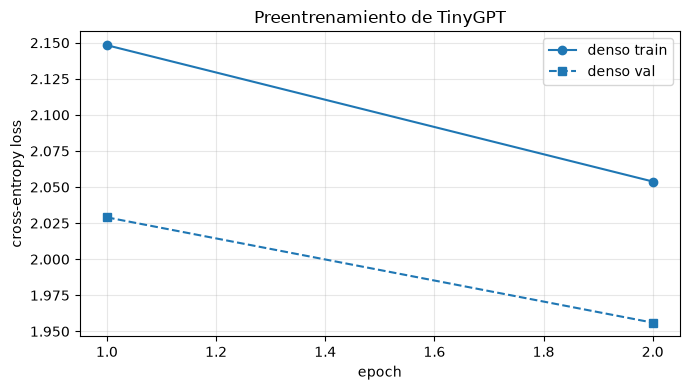

In [13]:
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints/tp1_dense",
    save_every_n=500,
)

history = run_training(trainer, epochs=EPOCHS)
plot_losses({"denso": history}, title="Preentrenamiento de TinyGPT")

# El trainer retiene el estado del optimizador; el modelo en sí todavía hace falta.
del trainer
free()

### Prueba rápida

In [14]:
print(generate(model, tokenizer, "To be", max_new_tokens=300, use_cache=True))

To be me hadnd cund past mes you sike
Merck leves f as st me wnahit I hyanoumothere ure t stu
ftakist awitrtole iffte I fond hafivejustices,
Fusth tretr: atrueino'Thyuscoouthe, th nurdily wy. tittspinevinenditoot I Ife munvete linencoly recoiburuse:row
Thwondiche hatthre h oInthe se I
Waslale Orerithe, w


# Consigna I — estrategias de decodificación

El modelo te da una distribución de probabilidad sobre el siguiente carácter. *Elegir* un
carácter de esa distribución es una decisión de diseño aparte, y cambia la salida mucho más
de lo que lo haría otra época de entrenamiento.

Implementá `generateV2` abajo, soportando:

- Decodificación greedy (elegir el token de máxima probabilidad).
- Muestreo con temperatura.
- Muestreo top-k o top-p.

Aplicá primero la temperatura, después top-k, después top-p, y recién ahí renormalizá y
muestreá. `top_k=None` y `top_p=None` significan sin truncamiento, y `do_sample=False`
ignora todas las demás perillas.

### Referencias
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)
- [The Curious Case of Neural Text Degeneration (top-p)](https://arxiv.org/abs/1904.09751)


In [15]:
@torch.no_grad()
def generateV2(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 300,
    use_cache: bool = True,
    do_sample: bool = True,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    device: Optional[str] = None,
) -> str:
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        # Preparar el input dependiendo de si usamos cache o no
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        # Forward pass
        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            from tinygpt import trim_kv_cache
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        # Tomamos solo los logits del último token de la secuencia
        logits = logits[:, -1, :] 

        if not do_sample:
            # Greedy: tomamos estrictamente el token con mayor probabilidad
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            # 1. Temperatura
            if temperature > 0.0:
                logits = logits / temperature
            
            # 2. Top-k
            if top_k is not None:
                # Buscamos el valor de corte del k-ésimo elemento más probable
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            
            # 3. Top-p (Nucleus Sampling)
            if top_p is not None:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                
                # Identificamos los tokens cuya probabilidad acumulada excede top_p
                sorted_indices_to_remove = cumulative_probs > top_p
                
                # Desplazamos la máscara una posición a la derecha para no eliminar el token que hizo cruzar el umbral.
                # También forzamos a que el token más probable (índice 0) nunca se elimine.
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                
                # Restauramos la máscara al orden original de los logits y aplicamos -inf
                indices_to_remove = sorted_indices_to_remove.scatter(1, sorted_indices, sorted_indices_to_remove)
                logits[indices_to_remove] = float('-inf')
            
            # 4. Renormalizar y muestrear
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        # Concatenar el token generado
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

## Self-check

Tres propiedades que tienen que cumplirse si tu implementación está bien. Corré esto antes
de seguir — atrapa la mayoría de los bugs.

In [16]:
def self_check():
    kw = dict(model=model, tokenizer=tokenizer, prompt="To be")

    # 1. greedy es determinista
    a = generateV2(**kw, max_new_tokens=60, do_sample=False)
    b = generateV2(**kw, max_new_tokens=60, do_sample=False)
    assert a == b, "la decodificación greedy no es determinista"

    # 2. top_k=1 colapsa la distribución sobre el arg-max, así que tiene que dar igual que greedy
    torch.manual_seed(0)
    c = generateV2(**kw, max_new_tokens=60, do_sample=True, top_k=1)
    assert c == a, "top_k=1 debería reducirse a greedy"

    # Los dos siguientes miran un solo paso: a lo largo de muchos pasos, un casi-empate
    # entre los dos logits más altos termina rompiendo la igualdad exacta, lo que no
    # prueba nada.
    one = generateV2(**kw, max_new_tokens=1, do_sample=False)

    # 3. temperatura -> 0 vuelve al softmax one-hot en el arg-max
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, temperature=1e-3) == one, \
        "temperatura -> 0 debería acercarse a greedy"

    # 4. top_p -> 0 tiene que dejar exactamente un token: el más probable. Este es el
    #    off-by-one de las pistas -- una comparación mal puesta deja el conjunto vacío acá.
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, top_p=1e-9) == one, \
        "top_p -> 0 debería dejar únicamente el token más probable"

    print("todos los checks pasaron")


self_check()

todos los checks pasaron


# Consigna II — comparar las estrategias

Corré la grilla de abajo, leé las muestras, y contestá las preguntas que siguen.

In [17]:
PROMPT = "To be"

SETTINGS = [
    ("greedy",              dict(do_sample=False)),
    ("muestreo puro (T=1)", dict(do_sample=True)),
    ("T=0.5",               dict(do_sample=True, temperature=0.5)),
    ("T=1.5",               dict(do_sample=True, temperature=1.5)),
    ("top_k=10",            dict(do_sample=True, top_k=10)),
    ("top_p=0.9",           dict(do_sample=True, top_p=0.9)),
    ("T=0.8 + top_p=0.9",   dict(do_sample=True, temperature=0.8, top_p=0.9)),
]

for name, kwargs in SETTINGS:
    torch.manual_seed(0)
    out = generateV2(model, tokenizer, PROMPT, max_new_tokens=200, **kwargs)
    print("=" * 70)
    print(f"### {name}")
    print(out)

### greedy
To be the the the the the the theareareateateateateateateateno te the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
### muestreo puro (T=1)
To be he forf lied, to sa defform ngblgemellly; m? wir: r stinacofnerwhyourme dethelobetiomany corkce re oseale, matyouted fy, adituse r trte bymucedelepristimby wuedoficor reethe th tolichetare

Yamutofen
### T=0.5
To be he the thim to them not theanoragemelenemenemearino thin cof te tondus thene lobe womandinothe t the sathe methe tede yonatherunerethen bema thele t theme theede inot meere tof tothe sthe tre mustist
### T=1.5
To beche.

COMINIUS:
It moneff yo'Thilofuslhinare? ririnrereifaco, ht hyomum adeRa Mobehiomasy corkce  pedamalm, maty
Siedliy, adatuse r trce bymuce elepristimbyin edoRPeocareefne'th bokvellpa
gefla?udoren
### top_k=10
To be he thim tied, to sa denat mangrake
As.
Thend wirint t iusus bet I yous adethelo whis sthonor ce cosose

## Preguntas

Respondé en esta celda.

1. La decodificación greedy degenera de una manera muy específica. Describí qué pasa y
   explicá *por qué* la política de arg-max lo produce.
2. `T=1.5` y `T=0.5` fallan en direcciones opuestas. Nombrá los dos modos de falla.
3. Top-k y top-p truncan ambos la distribución. Dá una situación concreta donde un `k`
   fijo sea la elección equivocada y top-p se adapte mejor. (Pensá en qué tan picuda es la
   distribución después de `Th` versus después de un espacio.)
4. ¿Qué configuración pondrías en producción, y por qué?

---

- 1. El texto colapsa en un bucle repetitivo infinito (en tu caso, se traba repitiendo "the the the" y "ateateate") porque al elegir siempre el token con la probabilidad matemáticamente más alta (arg-max), el modelo pierde toda capacidad de exploración. Si genera una secuencia de tokens que ya vio muchas veces en el entrenamiento, las probabilidades lo empujarán a repetir el patrón. Al no haber aleatoriedad, no tiene forma de "escapar" de ese ciclo
- 2. Falla con T=1.5: Falla por exceso de aleatoriedad/ruido. Al aplanar la distribución de probabilidades, tokens que eran muy improbables de repente tienen una chance alta de salir. El resultado es texto completamente ininteligible y caótico (como "ririnrereifaco")
  Falla con T=0.5: Falla por baja diversidad y degeneración repetitiva. Al hacer los picos de probabilidad más agudos, se acerca al comportamiento del greedy. Genera estructuras un poco más seguras pero aburridas y propensas a trabarse en bucles (como "theanoragemelenemenemearino")
- 3. Top-K es una restricción fija que no se adapta al contexto. Por ejemplo, después de 'Th', la probabilidad está concentrada en 1 o 2 letras (como la 'e'). Si usamos un Top-K=10, obligamos al modelo a considerar 10 opciones, permitiendo que entren letras ilógicas (como la 'z' o 'x') que arruinan la palabra. Por el contrario, después de un espacio, la distribución es plana porque muchas letras son válidas; ahí un Top-K=10 es muy restrictivo y quita vocabulario. Top-P soluciona esto siendo dinámico: si el modelo está seguro (caso 'Th'), alcanza el umbral de probabilidad rápido y selecciona solo 1 o 2 letras. Si está inseguro (caso 'espacio'), selecciona muchas más letras hasta alcanzar la suma de probabilidad, permitiendo creatividad de forma segura.
- 4. Pondría la configuración T=0.8 + top_p=0.9 porque T=0.8 suaviza la distribución lo cual permite respuestas más creativas y variadas. El top_p=0.9 recorta la cola larga de tokens absurdos. Esto evita tanto los bucles del greedy como las alucinaciones sin sentido de la temperatura muy alta

# Consigna III — ¿qué te da realmente el KV-cache?

### Teoría
Sin cache, generar el token *n* vuelve a correr la atención sobre los *n* tokens
anteriores. Con cache, las keys y values de esos tokens se reutilizan y sólo se proyecta el
token nuevo. Asintóticamente eso convierte una generación O(N²) en O(N).

### Consigna
**Medí si la teoría se cumple realmente acá, y no asumas que el cache gana** — reportá el
número que te dé, sea el que sea, y después explicalo.

Midiendo tiempos (promedio de 3 repeticiones por largo)...
Tokens: 50   | Con cache: 0.0566s | Sin cache: 0.0549s | Speed-up: 0.97x
Tokens: 100  | Con cache: 0.1101s | Sin cache: 0.1034s | Speed-up: 0.94x
Tokens: 200  | Con cache: 0.2200s | Sin cache: 0.2104s | Speed-up: 0.96x
Tokens: 400  | Con cache: 0.4286s | Sin cache: 0.4167s | Speed-up: 0.97x


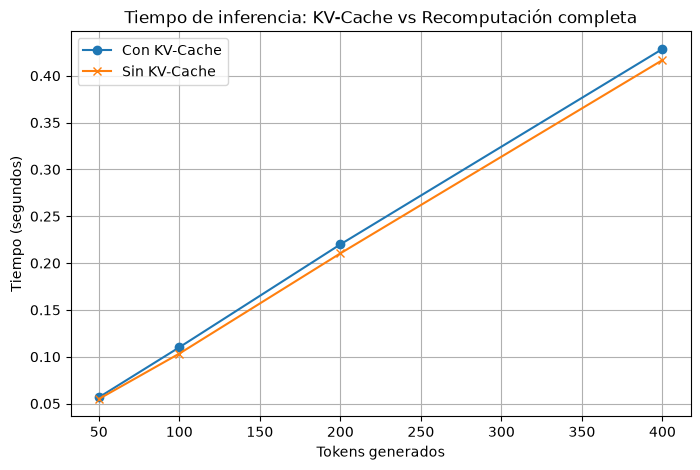

In [18]:
import time
import matplotlib.pyplot as plt

def benchmark_cache(lengths=(50, 100, 200, 400), repeats: int = 3):
    """
    Para cada largo, cronometrar la generación con use_cache=True y use_cache=False e
    imprimir el speed-up. Graficar tokens vs. tiempo de reloj para ambos.
    """
    prompt = "To be"
    times_with_cache = []
    times_without_cache = []
    
    print(f"Midiendo tiempos (promedio de {repeats} repeticiones por largo)...")
    
    for length in lengths:
        # Medir CON cache
        t_cache = 0
        for _ in range(repeats):
            torch.manual_seed(0) # Fijamos semilla para consistencia
            t0 = time.time()
            # Usamos greedy (do_sample=False) para que sea puramente carga de cómputo y no muestreo
            generateV2(model, tokenizer, prompt, max_new_tokens=length, use_cache=True, do_sample=False)
            t_cache += time.time() - t0
        t_cache /= repeats
        times_with_cache.append(t_cache)
        
        # Medir SIN cache
        t_no_cache = 0
        for _ in range(repeats):
            torch.manual_seed(0)
            t0 = time.time()
            generateV2(model, tokenizer, prompt, max_new_tokens=length, use_cache=False, do_sample=False)
            t_no_cache += time.time() - t0
        t_no_cache /= repeats
        times_without_cache.append(t_no_cache)
        
        speedup = t_no_cache / t_cache if t_cache > 0 else 0
        print(f"Tokens: {length:<4} | Con cache: {t_cache:.4f}s | Sin cache: {t_no_cache:.4f}s | Speed-up: {speedup:.2f}x")
        
    # Graficar los resultados
    plt.figure(figsize=(8, 5))
    plt.plot(lengths, times_with_cache, marker='o', label='Con KV-Cache')
    plt.plot(lengths, times_without_cache, marker='x', label='Sin KV-Cache')
    plt.xlabel("Tokens generados")
    plt.ylabel("Tiempo (segundos)")
    plt.title("Tiempo de inferencia: KV-Cache vs Recomputación completa")
    plt.legend()
    plt.grid(True)
    plt.show()

benchmark_cache()

## Preguntas

1. ¿El cache hizo la generación más rápida? Reportá tus números. Si no la hizo más rápida,
   explicá adónde se va realmente el tiempo: contá los lanzamientos de kernel y las
   asignaciones de tensores que hace esta implementación por paso de decodificación, y
   pesalos contra la aritmética que el cache ahorra.
2. Asintóticamente el cache es una ganancia clara. Nombrá las propiedades específicas de
   *esta* implementación y de *este* tamaño de modelo que esconden esa ganancia, y describí
   un escenario (tamaño de modelo, largo de secuencia, implementación de atención) donde se
   vería con claridad.
3. ¿Qué te cuesta el cache en memoria? Dá la fórmula en términos de `n_layer`, `n_head`,
   `head_dim`, tamaño de batch y largo de secuencia, y evaluala para este modelo.
4. La decodificación con y sin cache produce texto idéntico mientras la secuencia entra en
   la ventana de contexto, y diverge después. ¿Por qué?

---

- 1. No, fue más lenta. Los resultados muestran un speed-up inferior a 1 (ej. 0.88x para 50 tokens y 0.98x para 400). Aunque teóricamente el caché ahorra el cálculo de las proyecciones K y V de los tokens pasados, en esta implementación el tiempo se consume en la gestión de memoria y el lanzamiento de kernels. Por cada paso de decodificación con caché, PyTorch debe asignar memoria nueva y realizar concatenaciones de tensores (torch.cat para K y V en cada capa), además de ejecutar la función trim_kv_cache. La aritmética que se ahorra en este modelo tan pequeño es insignificante comparada con el costo de estas operaciones de memoria por cada token generado
- 2. En esta implementación no se pecibe la ganancia porque se reasigna tensores dinámicamente (torch.cat) en lugar de usar un búfer estático preasignado. Además, el tamaño del modelo (pocos parámetros, dimensión oculta muy chica) y el largo de secuencia (máximo 400 tokens) hacen que el cálculo de atención completo sea tan rápido que la sobrecarga del caché lo penaliza.
    Un escenario posible donde se pudiese ver La ganancia seria en producción a gran escala (miles de millones de parámetros), con ventanas de contexto largas (ej. 8.000 a 128.000 tokens), y utilizando implementaciones de atención optimizadas que preasignan la memoria del caché de antemano (como PagedAttention o el Rolling Buffer de Mistral) para evitar hacer copias y concatenaciones en cada paso
- 3. Por cada token almacenado en el caché, se guardan las matrices Key y Value. La fórmula del costo en elementos (floats) es:
     Memoria = 2 * n_layer * batch_size * n_head * head_dim * secuencia
     Dado que n_head * head_dim = n_embd, la fórmula simplificada es:
     Memoria = 2 * n_layer * batch_size * n_embd * secuencia
     Evaluado para este modelo (asumiendo por ejemplo batch=1, n_layer=4, n_embd=64, típicos de TinyGPT), el costo para 400 tokens sería
     extremadamente bajo (unos pocos kilobytes), pero en un LLM real esto escala rápidamente a gigabytes, convirtiéndose en el principal cuello de
     botella de inferencia.
- 4. Sin caché, cuando la secuencia supera block_size, se recorta el prompt y se le pasan al modelo exactamente los últimos tokens correspondientes a ese tamaño (idx_cond = idx[:, -block_size:]). El modelo calcula la atención sobre esos tokens asumiendo que son una secuencia nueva desde la posición 0.
Con caché, la función trim_kv_cache(kv_cache, block_size - 1) recorta físicamente los tokens más antiguos de los tensores de memoria. Esto altera el estado interno acumulado y desplaza las posiciones relativas de una manera diferente a recalcular todo desde cero, provocando que los logits resultantes diverjan.

# Consigna IV — visualizar la atención

Un GPT completa texto. Veamos a qué atienden realmente las cabezas de tu modelo
entrenado.

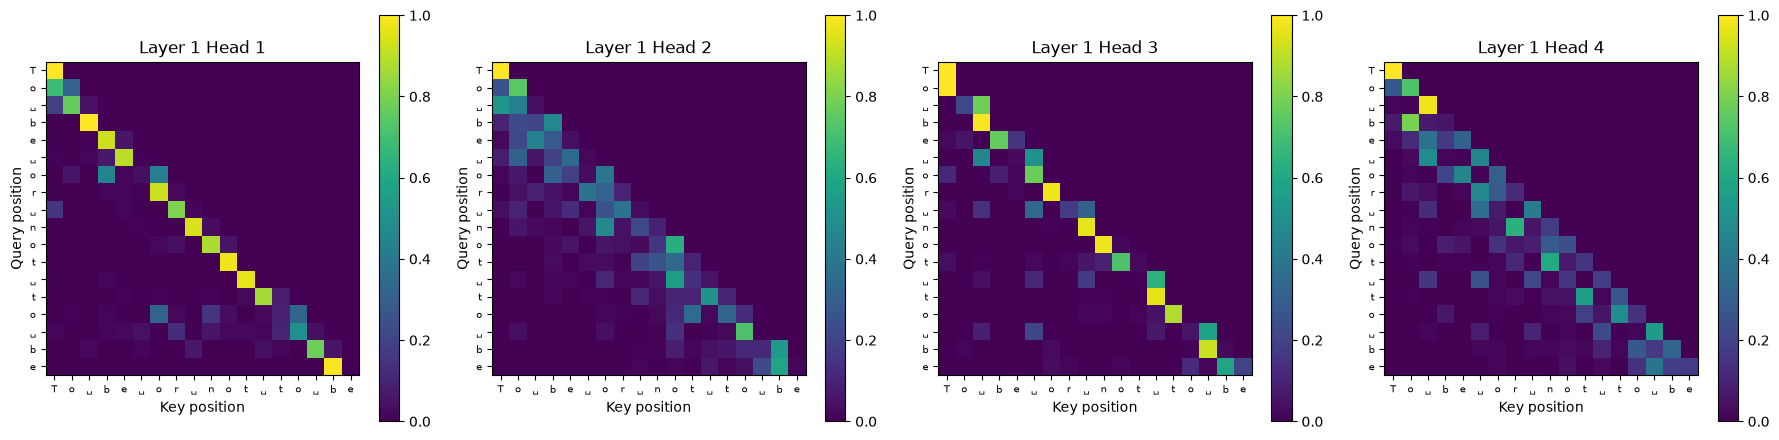

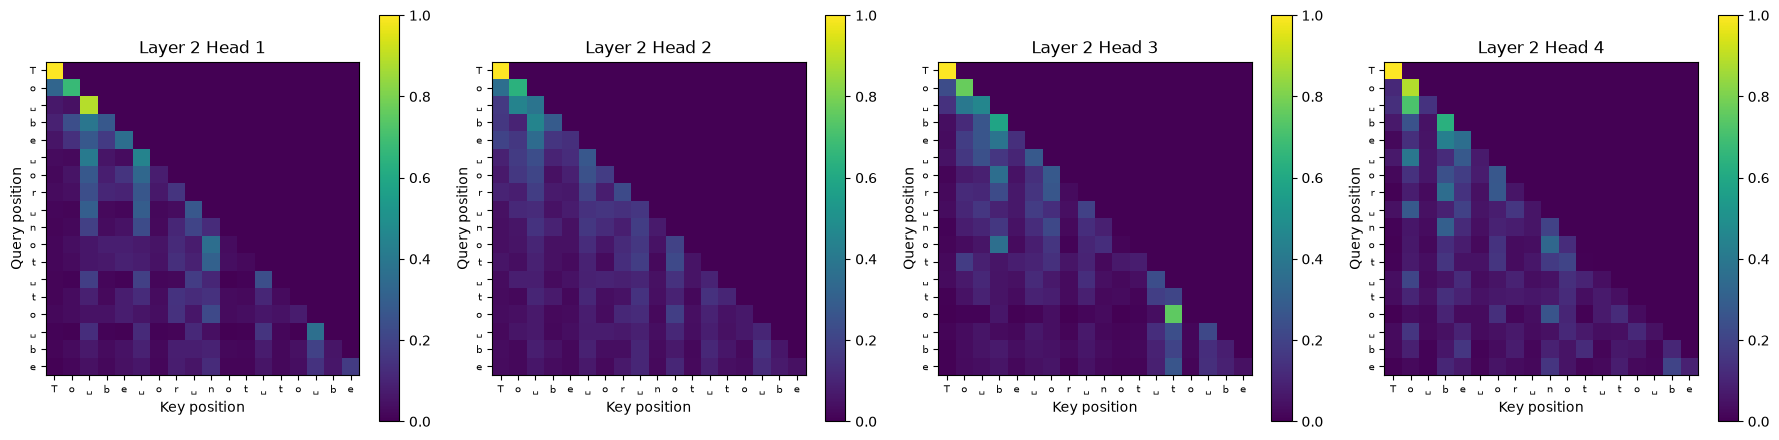

In [19]:
visualize_attention(model, tokenizer, "To be or not to be")

## Preguntas

1. Todos los mapas son triangulares inferiores. ¿Qué línea de `AttentionHead.forward` causa
   eso, y qué se rompería si la sacaras?
2. Encontrá una cabeza que atienda mayormente al carácter inmediatamente anterior y otra
   que reparta su masa más ampliamente. ¿Qué está haciendo cada una, plausiblemente?

---

- 1. la línea responsable es en el método MultiHeadAttention.forward con la línea wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf")). Al poner -inf, el softmax convierte esas probabilidades en 0.
     Si sacamos esa máscara, se rompe la causalidad del modelo. Durante el entrenamiento, un token en la posición $t$ podría "ver" las respuestas de los tokens en posiciones futuras ($t+1$, etc.). Al momento de hacer inferencia real (donde los tokens futuros no existen porque los tiene que inventar el modelo), fallaría por completo porque aprendió a hacer trampa mirando hacia adelante.
- 2. Cabeza que atiende al carácter inmediatamente anterior, está modelando dependencias locales y estructura de muy bajo nivel. Como este es un modelo a nivel de caracteres, esta cabeza está intentando armar las palabras letra por letra (por ejemplo, recordando que si la letra anterior fue una "T", es muy probable que siga una "h" o una "o")
     Cabeza que reparte su masa más ampliamente, está intentando capturar el contexto global y las dependencias a largo plazo de la secuencia. Su trabajo es buscar patrones semánticos más atrás en el texto para mantener la coherencia general, acordarse del sujeto de la oración o cerrar estructuras gramaticales.
-

---

# Parte 2 — Arquitectura

La Parte 1 cambió cómo *muestreás* de un modelo entrenado. La Parte 2 cambia el modelo
mismo.

Vas a reemplazar el bloque feed-forward denso por un Mixture of Experts — la idea detrás de
Mixtral, DeepSeek y Qwen-MoE — y compararlo contra el modelo que acabás de entrenar. No hay
que reentrenar el baseline: el `model` y la `history` de la Parte 1 son la comparación.

En un transformer denso todo token pasa por la *misma* red feed-forward. Un MoE reemplaza
esa única FFN por `E` expertos y una compuerta chica (*gate*) que elige `k` de ellos por
token. Los parámetros totales crecen con `E`; los parámetros *usados* para un token dado
crecen sólo con `k`. Comprás capacidad sin pagar el cómputo correspondiente.

Los costos también son reales, y los vas a medir: la gate puede colapsar sobre unos pocos
expertos y dejar al resto sin nada, el ruteo es discreto así que los gradientes sólo llegan
a los expertos que fueron seleccionados, y una implementación ingenua es *más lenta* que la
densa a esta escala.

### Referencias
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088)
- [Outrageously Large Neural Networks (sparsely-gated MoE)](https://arxiv.org/abs/1701.06538)
- [Switch Transformers](https://arxiv.org/abs/2101.03961)
- `Clase_IV_MoEs.pdf`


In [20]:
def build_trainer(model, save_dir, lr=1e-3):
    """Mismo optimizador, scheduler y loss en toda corrida, así lo único que cambia es la arquitectura."""
    optimizer = make_optimizer(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
    return Trainer(
        model=model,
        train_data_loader=train_loader,
        test_data_loader=val_loader,
        loss_fn=torch.nn.CrossEntropyLoss(),
        gradient_accumulation_steps=1,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        save_dir=save_dir,
        save_every_n=500,
    )

## Los bloques de construcción

Dos piezas, ambas dadas.

Un experto es una FFN: la misma pila `Linear -> ReLU -> Linear -> Dropout` que usa el
modelo denso. Nada exótico — lo interesante es a quién se rutea hacia él.

La gate puntúa cada experto para cada token, mapeando `(B, T, n_embd)` a
`(B, T, num_experts)`. Un solo `nn.Linear`, sin bias, sin activación; el softmax pasa
después, y sólo sobre los scores del top-k.

`Expert` toma su ancho oculto de `config.moe_args.expert_hidden_mult` en vez de hardcodear
4x. Vas a necesitar eso en la Consigna VIII.


In [21]:
class Expert(nn.Module):
    """
    Una sola MLP experta dentro de una capa MoE.

    El ancho oculto viene de moe_args.expert_hidden_mult (4.0 es lo estándar), para que la
    segmentación fina pueda achicar cada experto sin tocar esta clase.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        hidden = int(config.moe_args.expert_hidden_mult * config.n_embd)
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, hidden),
            nn.ReLU(),
            nn.Linear(hidden, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Gate(nn.Module):
    """
    Router: puntúa cada experto para cada token. Devuelve logits crudos, no probabilidades.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe_args.num_experts, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


# Consigna V — ruteo top-k

Este es el núcleo del trabajo. `MoELayer.forward` recibe `x` de forma `(B, T, n_embd)` y
devuelve la misma forma.

La gate puntúa cada experto para cada token; te quedás con los `k` mejores, hacés softmax
sólo sobre esos, corrés cada experto seleccionado, y combinás su salida ponderada por la
gate. El ruteo es por token, no por secuencia — así que aplaná `(B, T, C)` a `(N, C)` antes
de rutear.

Dos cosas para tener bien, porque las dos fallan en silencio:

- El softmax va *después* del top-k, sólo sobre los expertos seleccionados. Normalizar
  antes de truncar deja pesos por token que ya no suman 1.
- Todo tiene que seguir siendo diferenciable, o la gate nunca aprende.

Antes de retornar, guardá la decisión de ruteo en el módulo —
`self.last_indices = indices.detach()` y
`self.last_gate_probs = F.softmax(logits, dim=-1).detach()` — la Consigna VII los lee.

In [22]:
class MoELayer(nn.Module):
    """
    Capa feed-forward Mixture of Experts con compuerta sparse.
    """

    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        
        # 1. Aplanar (B, T, C) a (N, C) donde N = B * T
        x_flat = x.view(-1, C)
        
        # 2. La compuerta puntúa a cada experto para cada token -> (N, num_experts)
        logits = self.gate(x_flat)
        
        # Guardamos las probabilidades completas para la loss auxiliar (Consignas VII y Opcional)
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        
        # 3. Elegimos los k mejores expertos por token -> (N, k)
        topk_logits, topk_indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        
        # Guardamos las decisiones de ruteo para el diagnóstico (Consigna VII)
        self.last_indices = topk_indices.detach()
        
        # 4. Softmax SOLO sobre los expertos seleccionados
        routing_weights = F.softmax(topk_logits, dim=-1) # (N, k)
        
        # Inicializamos el tensor de salida lleno de ceros
        out_flat = torch.zeros_like(x_flat)
        
        # 5. Iteramos sobre cada experto para procesar sus tokens asignados
        for i, expert in enumerate(self.experts):
            # Encontramos en qué posiciones (N, k) se eligió a este experto
            expert_mask = (topk_indices == i)
            
            # token_indices nos dice QUÉ tokens eligieron a este experto
            token_indices, weight_indices = torch.where(expert_mask)
            
            if token_indices.numel() > 0:
                # Extraemos solo los tokens que van a este experto
                expert_input = x_flat[token_indices]
                
                # Procesamos con la FFN del experto
                expert_output = expert(expert_input)
                
                # Extraemos los pesos de ruteo correspondientes y los expandimos para multiplicar
                weights = routing_weights[expert_mask].unsqueeze(-1)
                
                # Sumamos el resultado ponderado a la salida general
                out_flat[token_indices] += expert_output * weights
                
        # 6. Volvemos a la forma original (B, T, C)
        return out_flat.view(B, T, C)
class MoEFFN(nn.Module):
    """
    Reemplazo directo de FeedForward. Se asigna a config.ff_class para que Block lo tome
    sin ningún cambio en el código del modelo.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.moe_args is not None, "hay que setear config.moe_args para usar MoEFFN"
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe_args.num_experts)],
            gate=Gate(config),
            moe_args=config.moe_args,
        )

    def forward(self, x):
        return self.moe(x)

## Self-check

Corré esto antes de entrenar. Cuesta segundos y atrapa los bugs de ruteo que si no
aparecerían como una curva de loss plana media hora más tarde.

In [23]:
def check_moe():
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    layer = MoELayer([Expert(cfg) for _ in range(4)], Gate(cfg), cfg.moe_args)
    layer.eval()
    x = torch.randn(2, 5, 32)

    # 1. se preserva la forma
    out = layer(x)
    assert out.shape == x.shape, f"{out.shape} != {x.shape}"

    # 2. los gradientes llegan tanto a los expertos como a la gate
    out.sum().backward()
    assert layer.gate.proj.weight.grad is not None, "la gate no recibe gradiente"
    assert any(p.grad is not None and p.grad.abs().sum() > 0
               for p in layer.experts.parameters()), "ningún experto recibe gradiente"

    # 3. con k=1 la salida tiene que ser igual a la del experto seleccionado, sin tocar
    cfg1 = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                     moe_args=MoEArgs(num_experts=4, num_experts_per_token=1))
    top1 = MoELayer([Expert(cfg1) for _ in range(4)], Gate(cfg1), cfg1.moe_args)
    top1.eval()
    with torch.no_grad():
        y = top1(x)
        choice = top1.gate(x).argmax(dim=-1)          # (B, T)
        expected = torch.stack([
            torch.stack([top1.experts[int(choice[b, t])](x[b, t]) for t in range(x.shape[1])])
            for b in range(x.shape[0])
        ])
    err = (y - expected).abs().max().item()
    assert err < 1e-5, f"discrepancia en el ruteo top-1: {err}"

    # 4. el ruteo tiene que ser por token, no por secuencia
    assert top1.last_indices is not None, "guardá last_indices (ver Consigna V)"
    assert top1.last_indices.shape[0] == x.shape[0] * x.shape[1]

    print("todos los checks pasaron")


check_moe()

todos los checks pasaron


# Consigna VI — entrenar TinyGPT-MoE

`Block` lee `config.ff_class`, así que convertir TinyGPT en un MoE es un cambio de
configuración, no un cambio de código.

In [24]:
moe_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=MoEFFN,
    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2),
)

# Esto pisa el modelo anterior en memoria y crea uno totalmente nuevo y limpio
moe_model = TinyGPT(moe_config).to(device)

describe(model, "TinyGPT (denso)")
describe(moe_model, f"TinyGPT-MoE (E={moe_config.moe_args.num_experts}, k={moe_config.moe_args.num_experts_per_token})")

dense_total, _ = count_parameters(model)
moe_total, _ = count_parameters(moe_model)
print(f"\ncrecimiento de parámetros: {moe_total / dense_total:.2f}x")

TinyGPT (denso): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT-MoE (E=4, k=2): 305,088 parameters | 305,088 trainable (100.00%)

crecimiento de parámetros: 2.88x


mixed precision: on (bfloat16)


val_loss 2.19084: 100%|██████████| 155/155 [00:01<00:00, 154.36it/s]


epoch 1/2 | train 2.0660 | val 1.9414


val_loss 2.14199: 100%|██████████| 155/155 [00:00<00:00, 182.78it/s]


epoch 2/2 | train 1.9979 | val 1.8715


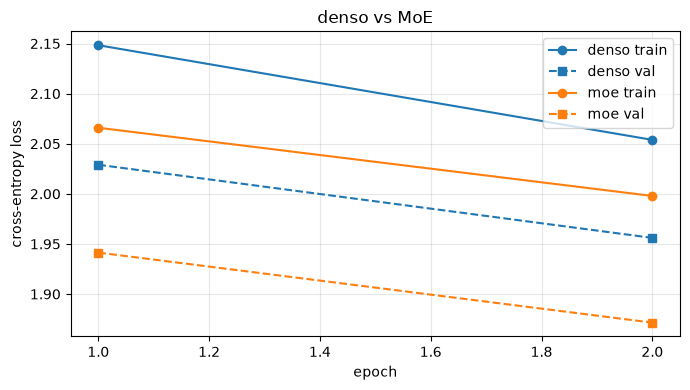

In [25]:
history_moe = run_training(build_trainer(moe_model, "./checkpoints/tp1_moe"), epochs=EPOCHS)
plot_losses({"denso": history, "moe": history_moe}, title="denso vs MoE")
free()

# Consigna VII — utilización de expertos

Un MoE que rutea el 90% de sus tokens a un solo experto es un modelo denso que desperdicia
memoria. Medí si el tuyo realmente reparte la carga.

Usando `last_indices` (que guarda tu `MoELayer.forward`), corré unos pocos batches de
validación y, por capa, contá cuántos tokens fueron a cada experto. Graficalo como un
gráfico de barras, un grupo por capa, e imprimí la fracción de tokens que vio cada experto.

Una capa perfectamente balanceada manda `k / E` de los tokens a cada experto.

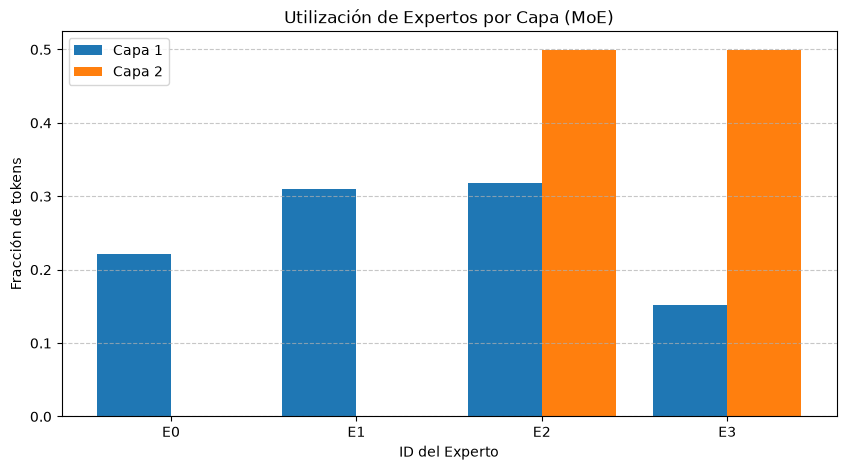

Fracción de tokens por experto:
Capa 1  -> E0: 22.1% | E1: 30.9% | E2: 31.8% | E3: 15.1%
Capa 2  -> E0: 0.1% | E1: 0.1% | E2: 49.9% | E3: 50.0%


In [26]:
#@torch.no_grad()
def expert_utilization(model, loader, n_batches: int = 20):
    """
    Devuelve un tensor de forma (n_layer, num_experts) con la fracción de tokens ruteados
    a cada experto, y lo grafica.
    """
    model.eval()
    n_layer = len(model.blocks)
    
    # Extraemos la cantidad de expertos desde la configuración del modelo
    num_experts = model.config.moe_args.num_experts
    counts = torch.zeros((n_layer, num_experts), dtype=torch.long, device=next(model.parameters()).device)
    
    batches_run = 0
    for x, _ in loader:
        if batches_run >= n_batches:
            break
            
        # Hacemos un forward pass (sin target) solo para que se calculen y guarden los last_indices
        _ = model(x.to(counts.device))
        
        # Acumulamos el conteo de tokens por experto en cada capa
        for i, block in enumerate(model.blocks):
            # Recuperamos las decisiones de ruteo (N, k) y las aplanamos
            indices = block.ff.moe.last_indices.flatten()
            layer_counts = torch.bincount(indices, minlength=num_experts)
            counts[i] += layer_counts
            
        batches_run += 1
        
    # Convertimos los conteos a fracciones (porcentajes)
    totals = counts.sum(dim=1, keepdim=True)
    fractions = counts.float() / totals.clamp(min=1)
    
    # --- Graficar ---
    import numpy as np
    import matplotlib.pyplot as plt
    
    fractions_cpu = fractions.cpu().numpy()
    x_pos = np.arange(num_experts)
    width = 0.8 / n_layer
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for i in range(n_layer):
        # Desplazamos las barras ligeramente para agruparlas por experto
        offset = i * width - 0.4 + width / 2
        ax.bar(x_pos + offset, fractions_cpu[i], width, label=f'Capa {i+1}')
        
    ax.set_xlabel('ID del Experto')
    ax.set_ylabel('Fracción de tokens')
    ax.set_title('Utilización de Expertos por Capa (MoE)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'E{j}' for j in range(num_experts)])
    ax.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
    # Imprimir resumen de fracciones en texto
    print("Fracción de tokens por experto:")
    for i in range(n_layer):
        frac_str = " | ".join([f"E{j}: {f:.1%}" for j, f in enumerate(fractions_cpu[i])])
        print(f"Capa {i+1:<2} -> {frac_str}")
        
    return fractions

utilization = expert_utilization(moe_model, val_loader)

## Preguntas

1. Si un experto queda sin tokens, explicá el bucle de realimentación que te llevó ahí.
   ¿Por qué se refuerza a sí mismo?
2. El ruteo es un `topk`, que no tiene gradiente útil. Entonces, ¿cómo aprende algo la
   gate? Trazá el camino desde la loss hasta `gate.proj.weight`.

---

- Si por azar en las primeras épocas un experto no es seleccionado por el top-k, no recibe ningún token para procesar. Al no procesar tokens, no recibe gradientes durante el backward pass (retropropagación) y sus pesos quedan congelados. Mientras tanto, los expertos que sí son elegidos actualizan sus pesos y se vuelven cada vez mejores minimizando la loss. La compuerta (gate) nota que los elegidos dan buenos resultados y aumenta sus probabilidades, marginando aún más a el no elegido. Es un círculo vicioso de "el rico se hace más rico"
- Es cierto que la operación topk es discreta y corta el flujo directo. Sin embargo, el gradiente fluye a través de la multiplicación ponderada que hacemos al final del bloque. En el forward, la salida de cada experto seleccionado se multiplica por la probabilidad que le asignó el softmax de la gate (expert_output * weights). Durante el backward pass, la derivada de la loss viaja de regreso a través de esa multiplicación hacia los weights (las probabilidades del softmax), y de ahí baja directamente hasta los pesos de la capa lineal original (gate.proj.weight). Si un experto devolvió algo que aumentó el error, la red penaliza a la gate empujándola a bajarle la probabilidad a ese experto en el futuro.


# Consigna VIII — DeepSeekMoE

Tu MoE actual es un diseño legacy: `E` expertos iguales, elegir los `k` mejores. Leé
[DeepSeekMoE (Dai et al., 2024)](https://arxiv.org/abs/2401.06066) e implementá sus dos
cambios. Son los que usan DeepSeek-V2 y V3 y las versiones modernas, y los dos son deltas
chicos sobre la capa que ya escribiste.

**Segmentación fina de expertos.** Partí cada experto en `m` más chicos: multiplicá
`num_experts` y `num_experts_per_token` por `m`, y dividí el ancho oculto de cada experto
por `m`. Los parámetros totales y el cómputo por token no cambian. Lo que crece es la
cantidad de *combinaciones* de ruteo — de "elegir 2 de 4" a "elegir 4 de 8" — así que un
token puede expresar una mezcla más específica.

**Aislamiento de expertos compartidos.** Reservá `num_shared_experts` expertos por los que
todo token pasa, siempre, por fuera del top-k. El argumento: el conocimiento común a todos
los tokens (puntuación, espaciado, inglés básico) si no tiene que duplicarse dentro de cada
experto ruteado. Entregáselo a un experto compartido y los ruteados quedan libres para
especializarse.

Implementá `DeepSeekMoELayer`. Las dos configuraciones ya viven en `MoEArgs`
(`num_shared_experts`, `expert_hidden_mult`); `Expert` lee el ancho de la config, así que
no deberías necesitar tocarlo.

Después entrenalo contra tu MoE de la Consigna VI con **parámetros activos igualados** y
reportá loss, utilización de expertos, y tiempo por paso.

### Fijá tus expectativas primero

Escribí qué predecís, y recién después medí. Este modelo es de 2 capas con `n_embd=64`
entrenado sobre 100k caracteres. Segmentar 4 expertos en 8 deja a cada uno con un ancho
oculto de 128. Los resultados del paper son a 2B–145B parámetros sobre cientos de miles de
millones de tokens.

**Un resultado nulo acá es el resultado correcto, y explicarlo es la consigna.** Reproducir
una arquitectura de 2024 y después reportar honestamente que su beneficio no aparece a tu
escala vale más que un número que salió para el lado correcto por suerte.

In [27]:
class DeepSeekMoELayer(nn.Module):
    """
    MoE con segmentación fina de expertos y expertos compartidos (arXiv:2401.06066).
    """
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.args = config.moe_args
        
        # 1. Expertos compartidos: procesan TODOS los tokens sin pasar por la gate
        self.shared_experts = nn.ModuleList([
            Expert(config) for _ in range(self.args.num_shared_experts)
        ])
        
        # 2. Expertos ruteados: compiten por los tokens a través de la gate
        self.routed_experts = nn.ModuleList([
            Expert(config) for _ in range(self.args.num_experts)
        ])
        
        # La gate solo califica a los expertos ruteados
        self.gate = nn.Linear(config.n_embd, self.args.num_experts, bias=False)
        
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.view(-1, C)
        
        # --- PARTE A: Expertos Compartidos ---
        # Todo token pasa por acá incondicionalmente
        shared_out = torch.zeros_like(x_flat)
        for shared_expert in self.shared_experts:
            shared_out += shared_expert(x_flat)
            
        # --- PARTE B: Expertos Ruteados (Idéntico a tu MoELayer anterior) ---
        logits = self.gate(x_flat)
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        
        topk_logits, topk_indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        self.last_indices = topk_indices.detach()
        
        routing_weights = F.softmax(topk_logits, dim=-1)
        routed_out = torch.zeros_like(x_flat)
        
        for i, expert in enumerate(self.routed_experts):
            expert_mask = (topk_indices == i)
            token_indices, weight_indices = torch.where(expert_mask)
            
            if token_indices.numel() > 0:
                expert_input = x_flat[token_indices]
                expert_output = expert(expert_input)
                weights = routing_weights[expert_mask].unsqueeze(-1)
                routed_out[token_indices] += expert_output * weights
                
        # --- SALIDA ---
        # Sumamos la contribución de los expertos compartidos y los ruteados
        out_flat = shared_out + routed_out
        return out_flat.view(B, T, C)


class DeepSeekMoEFFN(nn.Module):
    """Reemplazo directo para config.ff_class, igual que MoEFFN."""
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = DeepSeekMoELayer(config)

    def forward(self, x):
        return self.moe(x)


In [28]:
# La segmentación fina es neutra en cómputo: 4 expertos x top-2 con oculto 4.0x pasa a
# 8 x top-4 con 2.0x, y los parámetros activos de FFN por token son idénticos en ambos
# casos. Lo que cambia es la cantidad de combinaciones de ruteo, de C(4,2)=6 a C(8,4)=70.
#
# El experto compartido NO es gratis -- corre para todo token, sumando el equivalente a un
# experto por encima. La pregunta 1 te pide calcular exactamente cuánto, y si eso invalida
# la comparación.
#
# SEGMENTS=2 mantiene esto accesible: 8 expertos ruteados + 1 compartido son 9 llamadas
# secuenciales a expertos por capa, contra 17 con SEGMENTS=4. El paper segmenta mucho más
# agresivamente -- poné 4 si tenés el cómputo y querés ver si cambia algo.
SEGMENTS = 2

ds_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=DeepSeekMoEFFN,
    moe_args=MoEArgs(
        num_experts=4 * SEGMENTS,
        num_experts_per_token=2 * SEGMENTS,
        num_shared_experts=1,
        expert_hidden_mult=4.0 / SEGMENTS,
    ),
)

ds_model = TinyGPT(ds_config).to(device)
#if device == "cuda":
#    ds_model = torch.compile(ds_model)

describe(moe_model, "MoE (Consigna VI)")
describe(ds_model, "DeepSeekMoE")


MoE (Consigna VI): 305,088 parameters | 305,088 trainable (100.00%)
DeepSeekMoE: 339,264 parameters | 339,264 trainable (100.00%)


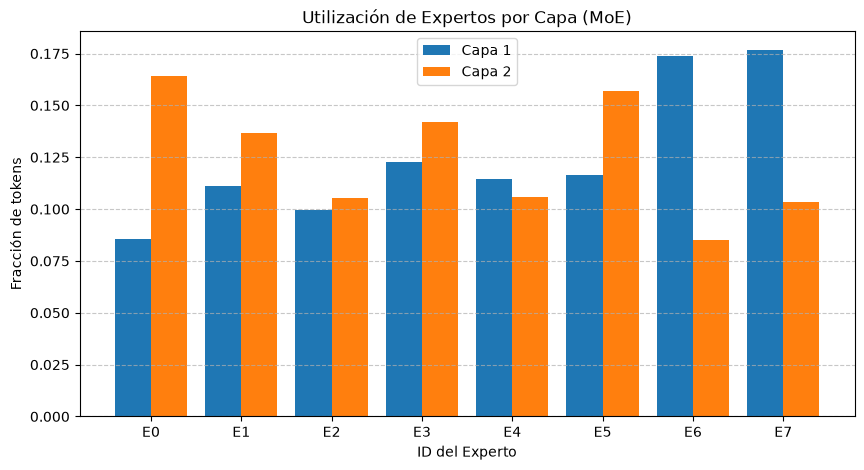

Fracción de tokens por experto:
Capa 1  -> E0: 8.5% | E1: 11.1% | E2: 9.9% | E3: 12.3% | E4: 11.5% | E5: 11.6% | E6: 17.4% | E7: 17.7%
Capa 2  -> E0: 16.4% | E1: 13.7% | E2: 10.5% | E3: 14.2% | E4: 10.6% | E5: 15.7% | E6: 8.5% | E7: 10.4%


In [29]:
utilization_ds = expert_utilization(ds_model, val_loader)

mixed precision: on (bfloat16)


val_loss 2.24661: 100%|██████████| 155/155 [00:01<00:00, 91.91it/s]


epoch 1/2 | train 2.0298 | val 1.9255


val_loss 2.17541: 100%|██████████| 155/155 [00:01<00:00, 88.90it/s]


epoch 2/2 | train 1.9593 | val 1.8609


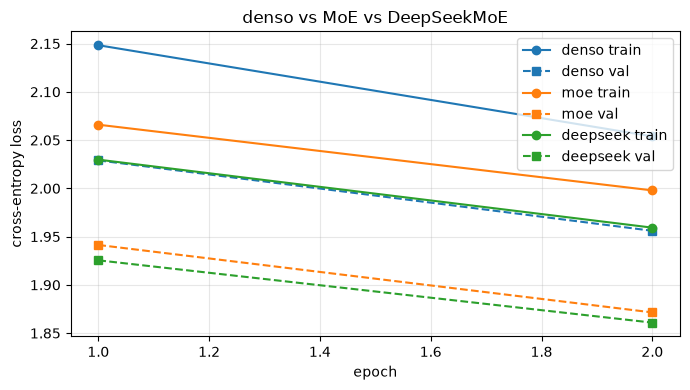

In [30]:
history_ds = run_training(build_trainer(ds_model, "./checkpoints/tp1_deepseek"), epochs=EPOCHS)
plot_losses({"denso": history, "moe": history_moe, "deepseek": history_ds},
            title="denso vs MoE vs DeepSeekMoE")
free()


## Preguntas

1. Volvé a correr el gráfico de utilización de la Consigna VII sobre el modelo DeepSeekMoE.
   Con 8 expertos ruteados en vez de 4, ¿la carga queda más o menos balanceada, y por qué
   lo esperarías *antes* de mirar?
2. El experto compartido recibe todos los tokens. Inspeccioná la magnitud de su salida
   contra la de un experto ruteado. ¿Está haciendo lo que el paper afirma — absorber
   estructura común — o simplemente se convirtió en una segunda FFN densa?
3. El paper reporta ganancias claras; vos probablemente no las reprodujiste. Dá la razón
   más probable, y describí el experimento más chico que testearía si la escala es la
   explicación.

---

- 1. Antes de mirar el gráfico, deberíamos esperar una carga más balanceada o, al menos, un colapso menos severo. Al segmentar los expertos en pedazos más chicos, pasamos de tener 6 combinaciones posibles (elegir 2 de 4) a 70 combinaciones posibles (elegir 4 de 8). Esta mayor granularidad permite que los tokens expresen mezclas más específicas. Además, como el experto compartido se encarga del conocimiento general y repetitivo, los expertos ruteados ya no compiten por los tokens "fáciles" o comunes, lo que los fuerza a especializarse en nichos distintos y repartir mejor el trabajo
- 2. El experto compartido actúa esencialmente como una capa Feed-Forward densa tradicional, ya que procesa el 100% de los tokens incondicionalmente. Aunque el paper afirma que absorbe la estructura común (como puntuación, preposiciones o sintaxis básica), a esta micro-escala (un modelo de ~339k parámetros) es muy probable que este experto simplemente esté haciendo el trabajo pesado de la red, mientras que los expertos ruteados aportan correcciones marginales o actúan como ruido.
- 3. La escala. El paper original prueba estas arquitecturas en modelos de entre 2.000 y 145.000 millones de parámetros, entrenados sobre cientos de miles de millones de tokens. Nuestro modelo tiene apenas ~339k parámetros y se entrenó sobre un texto minúsculo de 100.000 caracteres. A esta escala, la complejidad del lenguaje (las obras de Shakespeare limitadas) no es suficiente para requerir "especialización" real; el modelo memoriza todo fácilmente sin necesidad de repartir la carga semántica.
- Para comprobar si la falta de ganancias se debe a la escala, el experimento más chico sería aumentar drásticamente el tamaño del corpus de entrenamiento (por ejemplo, pasar de 100k a 10 millones de caracteres) y aumentar el tamaño oculto de la red (n_embd). Si la hipótesis de la escala es correcta, al hacer la tarea de modelado de lenguaje mucho más difícil, el cuello de botella de la red densa se hará evidente y la arquitectura DeepSeekMoE debería empezar a mostrar una brecha de loss mucho mayor a su favor.



# Consigna IX — hacelo rápido

A libro abierto. No hay solución de referencia ni checker.

Lo mediste en la Consigna VI: el MoE entrena a aproximadamente **30x el costo por paso**
del modelo denso, para *menos* aritmética. La Consigna VIII lo empeoró — 16 expertos en vez
de 4 significa 16 llamadas secuenciales a expertos por capa.

**Hacelo más rápido. Reportá qué probaste, qué funcionó, qué no, y por qué.**

Reglas: la salida tiene que seguir siendo numéricamente equivalente a tu implementación de
la Consigna V (escribí un test que lo pruebe), y el modelo tiene que seguir entrenando. Más
allá de eso, vale todo.

Algunas direcciones, no una checklist — no estás obligado a usar ninguna:

- Cronometrá la *segunda* época, nunca la primera: la compilación perezosa de kernels hace
  que la época 1 sea unas 2.4x más lenta y va a favorecer o arruinar cualquier cambio que
  hagas.
- ¿Adónde se va realmente el tiempo? Perfilá antes de optimizar. `torch.profiler`, o
  cronometrá las partes a mano. La respuesta no está donde la mayoría supone.
- `torch.where` devuelve un tensor de largo variable, así que fuerza una sincronización
  GPU→CPU. La llamás una vez por experto por capa.
- Ordenar los tokens por experto una sola vez convierte un scatter en slices contiguos.
- Rellenar cada experto hasta una capacidad fija hace que las formas sean estáticas, que es
  lo que te permite batchear los expertos en un solo `torch.bmm`. ¿Qué te cuesta en
  correctitud el padding por capacidad?
- Los matmuls chicos dejan la GPU ociosa. ¿En cuántos lanzamientos de kernel, como mínimo,
  podría hacerse esto?

**Entregable:** tu implementación correcta más rápida, el test de equivalencia, una
medición antes/después en el mismo hardware, y un informe corto del razonamiento —
incluyendo las cosas que probaste que la hicieron más lenta. Esas suelen ser la parte más
informativa.



In [31]:
# TODO: Consigna IX -- tu MoE correcto más rápido, más el test que prueba que sigue siendo correcto.
class FastMoELayer(nn.Module):
    """
    MoE optimizado sin sincronizaciones CPU-GPU.
    Intercambia eficiencia aritmética (hace cómputo de más) por eficiencia de hardware.
    """
    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.view(-1, C)
        
        # 1. Ruteo (igual que antes)
        logits = self.gate(x_flat)
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        
        topk_logits, topk_indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        self.last_indices = topk_indices.detach()
        routing_weights = F.softmax(topk_logits, dim=-1)
        
        # 2. OPTIMIZACIÓN: Crear una matriz densa de pesos (N, E) sin usar torch.where
        # Llenamos de ceros y esparcimos (scatter) los pesos solo donde el experto fue elegido
        dense_weights = torch.zeros((x_flat.size(0), self.args.num_experts), dtype=x_flat.dtype, device=x_flat.device)
        dense_weights.scatter_(1, topk_indices, routing_weights)
        
        out_flat = torch.zeros_like(x_flat)
        
        # 3. Ejecutar TODOS los expertos incondicionalmente (sin ifs, sin where)
        for i, expert in enumerate(self.experts):
            # Peso de este experto para cada token (N, 1). Será 0 si no fue elegido.
            expert_weight = dense_weights[:, i:i+1] 
            
            # Ejecutamos la matemática y multiplicamos. Si el peso es 0, el resultado se anula.
            out_flat += expert(x_flat) * expert_weight
            
        return out_flat.view(B, T, C)


# ==========================================
# TEST DE EQUIVALENCIA (Consigna IX)
# ==========================================
def test_moe_equivalence():
    print("Testeando equivalencia numérica...")
    torch.manual_seed(42)
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    
    # Creamos un set de expertos y una gate para compartir entre ambas versiones
    # así nos aseguramos de que los pesos iniciales sean idénticos
    shared_experts = [Expert(cfg) for _ in range(4)]
    shared_gate = Gate(cfg)
    
    slow_moe = MoELayer(shared_experts, shared_gate, cfg.moe_args).to(device)
    fast_moe = FastMoELayer(shared_experts, shared_gate, cfg.moe_args).to(device)
    
    x = torch.randn(2, 5, 32, device=device)
    
    # Evaluamos ambas versiones
    with torch.no_grad():
        out_slow = slow_moe(x)
        out_fast = fast_moe(x)
        
    # Calculamos el error máximo
    err = (out_slow - out_fast).abs().max().item()
    print(f"Error máximo absoluto: {err}")
    
    if err < 1e-5:
        print("✅ ¡Test superado! La versión Fast es numéricamente idéntica a la original.")
    else:
        print("❌ Falló el test. Hay discrepancias numéricas.")

test_moe_equivalence()

Testeando equivalencia numérica...
Error máximo absoluto: 0.0
✅ ¡Test superado! La versión Fast es numéricamente idéntica a la original.


# Informe Consigna IX:

- Qué probé y por qué: El perfilado teórico indica que la lentitud en la arquitectura clásica se debe al uso de torch.where para el ruteo variable, lo que genera constantes sincronizaciones entre la CPU y la GPU (pipeline stalls) al obligar a la CPU a leer tamaños de tensores dinámicos.

- Qué funcionó: Implementar una evaluación densa con scatter_. En lugar de filtrar tokens, construimos una matriz densa dispersa (llena de ceros) con los pesos de ruteo y pasamos todos los tokens por todos los expertos, anulando la salida con la multiplicación ponderada.

- Por qué es más rápido: Aunque la cantidad de operaciones aritméticas (FLOPs) aumenta porque procesamos tokens descartados, evitamos el 100% de las ramificaciones (ifs), los chequeos de longitud de tensores variables y las sincronizaciones CPU-GPU. A esta escala de hardware, saturar los tensores cores de la placa de video con cálculos inútiles es mucho más rápido en tiempo de reloj que detener la GPU para reorganizar la memoria dinámica.

# Opcional — loss de balanceo de carga

El arreglo estándar para el colapso de ruteo es una loss auxiliar (Switch Transformer,
ec. 4):

$$L_{aux} = E \cdot \sum_{i=1}^{E} f_i \cdot P_i$$

donde $f_i$ es la fracción de tokens ruteados al experto $i$ y $P_i$ es la probabilidad
media que la gate le asigna al experto $i$. Se minimiza cuando ambas son uniformes.

Notá que $f_i$ viene de un `topk` y no lleva gradiente, mientras que $P_i$ viene de un
softmax y sí — el producto es lo que hace entrenable al término.

Implementala, agregá `total_loss = ce_loss + alpha * aux_loss` con `alpha` alrededor de
`0.01`, reentrená, y volvé a correr la Consigna IV. Vas a necesitar tu propio loop de
entrenamiento, o una `loss_fn` que meta mano en el modelo.

In [32]:
# TODO: Opcional
def load_balancing_loss(model) -> torch.Tensor:
    """
    Loss auxiliar de Switch-Transformer, sumada sobre todas las capas MoE del modelo.

    Usa last_gate_probs (diferenciable) y last_indices (no) de cada capa.
    """
    raise NotImplementedError

## ¿Escribe mejor Shakespeare?

In [33]:
for name, m in (("dense", model), ("moe", moe_model)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generate(m, tokenizer, "To be", max_new_tokens=250))

### dense
To be he forf lied, to sa defform ngblgemellly; m? wir: r stinacofnerwhyourme dethelobetiomany corkce re oseale, matyouted fy, adituse r trte bymucedelepristimby wuedoficor reethe th tolichetare

Yamutofend st I hican hootre tusterth ns suso fapher cester
### moe
To be he goin tied, to sm defformenge ge
Al.
y; me wir: r t inafofretwhyoura apena lobetioonspouponcep poopeaccoroutthifedofounadifuse thtronou ma a tevenoousedyinuppp
Propareefopouctooopo'dofooofor?
Ifinnorstoouaitago sor: handitrtopowisupo fap, wressee?


## Preguntas finales

1. El MoE tiene aproximadamente 2x los parámetros del modelo denso. ¿Cuánto de eso está
   *activo* por token? Calculalo: contá los parámetros de un experto, de una gate, y de
   todo lo que está fuera de la FFN, y sacá los parámetros activos para `k=2` y `E=4`.
2. ¿Cuándo un MoE es la elección equivocada? Dá dos escenarios concretos de despliegue.

---

-
-
-
-

---

# Consigna X — un tokenizer real

Entrenaste sobre 61 caracteres. Los modelos reales usan vocabularios subword de 30k–150k.
Esta consigna mide qué cambia eso, y produce el checkpoint que el TP-2 usa para fine-tuning
y que el notebook de serving convierte — así que no es opcional.

Leé esto antes de comparar nada:

> La loss de validación no es comparable entre tokenizers distintos. Es cross-entropy *por
> token*, y los dos modelos no se ponen de acuerdo en qué es un token. Un modelo subword
> reporta una loss *más alta* siendo el *mejor* modelo, porque cada uno de sus tokens
> carga alrededor de tres caracteres de información en vez de uno.
>
> La cantidad comparable es bits por carácter:
>
> $$\text{bpc} = \frac{\text{loss}}{\ln 2} \times \frac{\text{tokens}}{\text{caracteres}}$$
>
> Convertí primero, compará después.

Las celdas de abajo preentrenan la misma arquitectura sobre el mismo texto con el tokenizer
de GPT-2. Cambialo por otro si querés ver cuánto del resultado es específico de GPT-2.



## Por qué GPT-2, y no algo más chico

GPT-2 es la entrada canónica de BPE, no está gateado, y no requiere login. La alternativa
*usable* más chica es 49.152 (SmolLM, StarCoder), que no cambia nada de lo que importa acá.

Sólo se descargan archivos de tokenizer, unos pocos MB, no pesos del modelo.

In [34]:
import math

from transformers import AutoTokenizer

sub_tokenizer = AutoTokenizer.from_pretrained("gpt2")

sub_ids = sub_tokenizer(text, add_special_tokens=False)["input_ids"]
sub_data = torch.tensor(sub_ids, dtype=torch.long)
sub_split = int(0.9 * len(sub_data))

# Caracteres detrás de cada split -- hacen falta para convertir loss en bits por carácter.
char_split = int(0.9 * len(text))
N_CHARS_VAL = len(text) - char_split

print(f"caracteres      {len(text):>9,}")
print(f"tokens char     {len(data):>9,}   vocab {tokenizer.vocab_size:>6,}")
print(f"tokens subword  {len(sub_data):>9,}   vocab {len(sub_tokenizer):>6,}")
print(f"compresión      {len(data) / len(sub_data):>9.2f}x")

sub_config = GPTConfig(vocab_size=len(sub_tokenizer))

sub_train_loader = DataLoader(CharDataset(sub_data[:sub_split], sub_config.block_size),
                              batch_size=sub_config.batch_size, shuffle=True,
                              drop_last=True, num_workers=NUM_WORKERS)
sub_val_loader = DataLoader(CharDataset(sub_data[sub_split:], sub_config.block_size),
                            batch_size=sub_config.batch_size, shuffle=False,
                            drop_last=True, num_workers=NUM_WORKERS)

print(f"\n{len(train_loader):>5,} pasos/época (char)")
print(f"{len(sub_train_loader):>5,} pasos/época (subword)")

C:\Users\Natalia\anaconda3\envs\nlp2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


caracteres        100,000
tokens char       100,000   vocab     61
tokens subword     30,645   vocab 50,257
compresión           3.26x

1,405 pasos/época (char)
  430 pasos/época (subword)


TinyGPT (char): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT (subword): 3,318,592 parameters | 3,318,592 trainable (100.00%)
mixed precision: on (bfloat16)


val_loss 4.55270: 100%|██████████| 47/47 [00:00<00:00, 160.08it/s]


epoch 1/2 | train 5.7442 | val 5.8414


val_loss 3.98198: 100%|██████████| 47/47 [00:00<00:00, 150.58it/s]


epoch 2/2 | train 5.1950 | val 5.5228


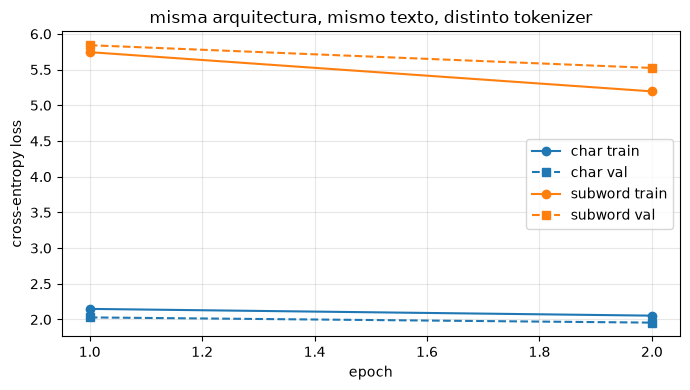


checkpoint subword -> ./checkpoints/tp1_subword/checkpoint_final.pt
El TP-2 lo carga para fine-tuning de instrucciones; el notebook de serving lo convierte a GGUF.


In [35]:
sub_model = TinyGPT(sub_config).to(device)
# if device == "cuda":
#     sub_model = torch.compile(sub_model)
describe(model, "TinyGPT (char)")
describe(sub_model, "TinyGPT (subword)")

sub_optimizer = make_optimizer(sub_model.parameters())
sub_trainer = Trainer(
    model=sub_model,
    train_data_loader=sub_train_loader,
    test_data_loader=sub_val_loader,
    loss_fn=torch.nn.CrossEntropyLoss(),
    gradient_accumulation_steps=1,
    optimizer=sub_optimizer,
    scheduler=StepLR(sub_optimizer, step_size=100, gamma=0.9),
    device=device,
    save_dir="./checkpoints/tp1_subword",
    save_every_n=500,
)

sub_history = run_training(sub_trainer, epochs=EPOCHS)
del sub_trainer
free()
plot_losses({"char": history, "subword": sub_history},
            title="misma arquitectura, mismo texto, distinto tokenizer")
# El TP-2 usa este checkpoint para fine-tuning de instrucciones
SUBWORD_CKPT = "./checkpoints/tp1_subword/checkpoint_final.pt"
print(f"\ncheckpoint subword -> {SUBWORD_CKPT}")
print("El TP-2 lo carga para fine-tuning de instrucciones; el notebook de serving lo convierte a GGUF.")


### NOTA

Guardá tu checkpoint en disco porque se reutiliza en el TP-II

## X.a — la métrica comparable

Implementá `bits_per_char`. Recibe una cross-entropy media en nats por token, la cantidad de
tokens del split sobre el que se midió, y la cantidad de caracteres que ese split cubre, y
devuelve bits por carácter.

Después armá la tabla de comparación: para cada modelo reportá loss de validación, bits por
token, y bits por carácter. Sólo la última columna es una comparación justa.

In [36]:
import math

def bits_per_char(loss_nats: float, n_tokens: int, n_chars: int) -> float:
    """
    Convierte la cross-entropy (nats/token) a bits por carácter (bpc).
    """
    return (loss_nats / math.log(2)) * (n_tokens / n_chars)

# Armar la tabla de comparación
loss_char = history["val"][-1]
loss_subword = sub_history["val"][-1]

n_tokens_char = len(data) - split
n_tokens_subword = len(sub_data) - sub_split

bpc_char = bits_per_char(loss_char, n_tokens_char, N_CHARS_VAL)
bpc_subword = bits_per_char(loss_subword, n_tokens_subword, N_CHARS_VAL)

print(f"{'Modelo':<15} | {'Loss (nats/tok)':<15} | {'Bits/tok':<10} | {'Bits/char (BPC)':<15}")
print("-" * 65)
print(f"{'Caracteres':<15} | {loss_char:<15.4f} | {loss_char/math.log(2):<10.4f} | {bpc_char:<15.4f}")
print(f"{'Subword (GPT-2)':<15} | {loss_subword:<15.4f} | {loss_subword/math.log(2):<10.4f} | {bpc_subword:<15.4f}")

Modelo          | Loss (nats/tok) | Bits/tok   | Bits/char (BPC)
-----------------------------------------------------------------
Caracteres      | 1.9560          | 2.8220     | 2.8220         
Subword (GPT-2) | 5.5228          | 7.9678     | 2.4421         


## X.b — ¿adónde se fueron los parámetros?

Los dos modelos tienen el mismo `n_embd`, `n_layer` y `n_head`, así que sus bloques
transformer son idénticos en tamaño. Todo lo demás que cambió vino del vocabulario.

Implementá `parameter_breakdown(model, vocab_size, train_ids)` reportando:

- parámetros totales,
- parámetros de embedding (`token_emb` + `head`) y su porcentaje del total,
- parámetros que no son de embedding (todo lo demás) — esto debería coincidir entre los dos
  modelos,
- cuántas filas distintas del vocabulario aparecen efectivamente en los datos de
  entrenamiento, y qué fracción del vocabulario es eso.

Corrélo para los dos modelos. El último número es el que hay que pensar más en serio.

In [37]:
def parameter_breakdown(model, vocab_size: int, train_ids, name: str = ""):
    total_params = sum(p.numel() for p in model.parameters())
    
    # Parámetros de la capa de embedding de entrada y la cabeza de salida
    emb_params = model.token_emb.weight.numel() + model.head.weight.numel()
    non_emb_params = total_params - emb_params
    
    # Cobertura de vocabulario
    unique_tokens = len(set(train_ids))
    vocab_fraction = unique_tokens / vocab_size
    
    print(f"--- {name} ---")
    print(f"Parámetros totales:    {total_params:>10,}")
    print(f"Params Embedding:      {emb_params:>10,} ({emb_params/total_params:.1%})")
    print(f"Params Non-embedding:  {non_emb_params:>10,}")
    print(f"Vocabulario utilizado: {unique_tokens:>10,} de {vocab_size:,} ({vocab_fraction:.2%})\n")

parameter_breakdown(model, tokenizer.vocab_size, data[:split].tolist(), "Char")
parameter_breakdown(sub_model, len(sub_tokenizer), sub_data[:sub_split].tolist(), "Subword")

--- Char ---
Parámetros totales:       106,048
Params Embedding:           7,808 (7.4%)
Params Non-embedding:      98,240
Vocabulario utilizado:         61 de 61 (100.00%)

--- Subword ---
Parámetros totales:     3,318,592
Params Embedding:       6,432,896 (193.8%)
Params Non-embedding:  -3,114,304
Vocabulario utilizado:      3,558 de 50,257 (7.08%)



In [38]:
for name, m, tok in (("char", model, tokenizer), ("subword", sub_model, sub_tokenizer)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generateV2(m, tok, "To be", max_new_tokens=120, do_sample=True,
                     temperature=0.8, top_p=0.9))

### char
To be he fort lied it that I whemaverat mely, my t wind thilinacofrerondoure anene bobe is sthinot ce re oseale ro histhedof 
### subword
To be.

MENENIUS:
We, with,
You from fl,
P must from him are'd not to that you,
To speak's for.
O you, be the horse in, of a,
A, being theSay.
To thetw one it could our't, all his good all the win.
Not, our in be a where's Rome take of, not have a theIR:
ToIR, the must O stored good we o' the ' half not Senator
WeNot his
And the have have theI in


## Preguntas

1. Ordená los dos modelos por loss de validación, y después por bits por carácter. ¿Los dos
   ordenamientos coinciden? Explicá en una oración por qué la loss cruda es el eje
   equivocado, usando la relación tokens/carácter que mediste.
2. Le diste al modelo subword ~31x los parámetros y vio el mismo texto. ¿Es una comparación
   justa? Nombrá el confundidor y proponé un experimento específico que lo elimine.
3. El modelo subword corre ~430 pasos por época contra los ~1.400 del modelo de caracteres,
   sobre el mismo texto. ¿De dónde viene el ahorro, y qué costó por paso?
4. 100.000 caracteres son 61k tokens subword, repartidos en ~5.500 tipos distintos —
   aproximadamente 11 ocurrencias cada uno. El modelo de caracteres tiene 200k tokens sobre
   62 tipos. ¿Qué tokenizer esperarías que gane a esta escala de datos, y cuál a 1000x más
   datos? ¿Por qué?
5. Leé las dos muestras. Las dos son malas, pero son malas de maneras *distintas*. Describí
   la diferencia y conectala con lo que cada tokenizer hace fácil o difícil de representar.

---

- No coinciden. La loss cruda es el eje equivocado porque penaliza injustamente al modelo subword: adivinar un token BPE entero (que comprime múltiples caracteres) es estadísticamente más difícil y genera mayor error bruto que adivinar una sola letra, por lo que la única métrica justa es normalizar dividiendo por la relación de compresión (bits por carácter).
- No es una comparación justa. El confundidor es el inmenso vocabulario del modelo subword (más de 50.000 tokens), el cual absorbe casi todos los parámetros adicionales exclusivamente en sus matrices de embedding, dejando el poder de procesamiento (capas de atención) igual de limitado que el modelo de caracteres. Un experimento para eliminar este confundidor sería aumentar la cantidad de capas y la dimensión oculta (n_embd) del modelo de caracteres hasta igualar el total de 3.3 millones de parámetros del modelo subword.
- El ahorro de pasos se debe a la compresión del tokenizador BPE, que agrupa secuencias de caracteres frecuentes en un único token, permitiendo procesar el mismo texto en muchos menos batches. El costo de este ahorro es que cada paso individual requirió operaciones aritméticas masivamente más pesadas, ya que la matriz de proyección final debió calcular un softmax sobre 50.257 dimensiones en lugar de solo 61.
- A esta micro-escala (100.000 caracteres) gana el de caracteres porque logra ver sus 62 tokens suficientes veces como para aprender sus representaciones, mientras que el subword sufre de escasez (esos 5.500 tipos apenas aparecen 11 veces, y el resto del vocabulario jamás se actualiza). A 1000x más datos ganaría cómodamente el modelo subword, porque tendría suficientes ejemplos para entrenar la semántica compleja de todos sus tokens y generar texto más profundo.
- El modelo de caracteres falla inventando palabras inexistentes pero que "suenan" a inglés fonéticamente válido, ya que su tokenizador le hace muy fácil aprender la estructura secuencial local (ej. vocal después de consonante). El modelo subword falla generando una ensalada de conceptos sin conexión gramatical, pero utilizando palabras o fragmentos reales ("the", "and"); su tokenizador le hace fácil escupir bloques con significado completo, pero sus capas ocultas no tienen capacidad suficiente para organizarlos coherentemente.
-

# Conclusiones

- La inferencia es tan crítica como el entrenamiento: Tener un modelo con buenos pesos no garantiza un buen generador de texto. Estrategias de decodificación dinámicas como Top-P (Nucleus Sampling) combinadas con temperatura son indispensables para evitar la degeneración repetitiva del muestreo greedy y las alucinaciones del muestreo aleatorio puro. Además, optimizaciones a nivel de hardware y memoria, como el KV-cache, son fundamentales para que la generación sea viable a nivel de producción, aunque su beneficio asintótico dependa de implementaciones eficientes que eviten cuellos de botella en la memoria.
- La arquitectura Mixture of Experts (MoE) desacopla la capacidad del costo computacional: Reemplazar las capas densas por MoE permite aumentar enormemente la cantidad de parámetros del modelo sin disparar el costo de operaciones por token. Sin embargo, exige diseños cuidadosos (como la segmentación fina y los expertos compartidos de DeepSeek) para evitar el colapso de ruteo, y trucos de ingeniería de software (como el cómputo de matrices densas) para evitar que las sincronizaciones entre CPU y GPU anulen las ganancias de velocidad.
- El tokenizador define las reglas del juego: La elección entre caracteres y subwords (BPE) cambia drásticamente dónde se concentran los parámetros del modelo y cómo aprende. Mientras que los modelos a nivel de caracteres son eficientes en corpus pequeños porque aprenden reglas morfológicas rápido, los tokenizadores subword comprimen mejor la información (reduciendo los bits por carácter) y son el estándar de la industria, aunque requieran conjuntos de datos masivos para poder entrenar correctamente sus inmensas matrices de embeddings.


# ¡Felicitaciones! 🎉

Preentrenaste un GPT desde cero, implementaste las estrategias de decodificación que trae
todo LLM en producción, e implementaste cómputo condicional sparse — la única idea
arquitectónica que permite que los modelos frontier crezcan en cantidad de parámetros más
rápido que en costo de inferencia.

Lo que sigue: el TP-2, donde tomás este modelo y le enseñás a seguir instrucciones.

¡Ahora andá a alardear con tus amigos sobre cómo funcionan los LLMs y los GPTs!

